# Caso A · Predicción de abandono de clientes (*Churn Prediction*)

---
**Dataset:`ChurnDataset.xlsx`, posee **5,630 registros** de clientes de un e-commerce cuyas algunas de las variables corresponden a las sugeridas por el Caso A.

### 1-Definiendo tipos de columnas

In [1]:
# Importando librerias

import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import seaborn as sb

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [2]:
# Importando dataset

df = pd.read_excel("Dataset/ChurnDataset.xlsx")
df.head(5)

,CustomerID,Gender,MaritalStatus,PreferredLoginDevice,PreferedOrderCat,TransactionCount,AvgTransactionAmount,DaySinceLastOrder,PromoInteractionCount,FlagComplain,Churn
0,50001,Female,Single,Mobile Phone,Laptop & Accessory,1.0,639.72,5.0,1.0,1,1
1,50002,Male,Single,Phone,Mobile,1.0,483.60,0.0,0.0,1,1
2,50003,Male,Single,Phone,Mobile,1.0,481.12,3.0,0.0,1,1
3,50004,Male,Single,Phone,Laptop & Accessory,1.0,536.28,3.0,0.0,0,1
4,50005,Male,Single,Phone,Mobile,1.0,518.40,3.0,1.0,0,1


In [3]:
# Validando tipos datos

print(df.shape)
df.info()

(5630, 11)
<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             5630 non-null   int64  
 1   Gender                 5630 non-null   str    
 2   MaritalStatus          5630 non-null   str    
 3   PreferredLoginDevice   5630 non-null   str    
 4   PreferedOrderCat       5630 non-null   str    
 5   TransactionCount       5372 non-null   float64
 6   AvgTransactionAmount   5630 non-null   float64
 7   DaySinceLastOrder      5323 non-null   float64
 8   PromoInteractionCount  5374 non-null   float64
 9   FlagComplain           5630 non-null   int64  
 10  Churn                  5630 non-null   int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 484.0 KB


**Conclusión estructura datos:**  Tres variables numéricas presentan valores nulos: `TransactionCount`, `DaySinceLastOrder` y `PromoInteractionCount`.

### 2-Definiendo tipos de columnas

In [4]:
# Definiendo tipos de columnas

col_id = ["CustomerID"]

cols_numericas = ["TransactionCount", "AvgTransactionAmount", "DaySinceLastOrder", "PromoInteractionCount"]

cols_categoricas = ["PreferredLoginDevice", "PreferedOrderCat", "FlagComplain"]

cols_sensibles = ["Gender", "MaritalStatus"]   

col_target = ["Churn"]
target = col_target[0]

cols_modelo = cols_numericas + cols_categoricas   

### 3-Estandarizando categorías

In [5]:
# Validando valores unicos de las variables categoricas

for col in cols_categoricas + cols_sensibles:
    print(col, ":", df[col].unique().tolist())

PreferredLoginDevice : ['Mobile Phone', 'Phone', 'Computer']
PreferedOrderCat : ['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']
FlagComplain : [1, 0]
Gender : ['Female', 'Male']
MaritalStatus : ['Single', 'Divorced', 'Married']


**Conclusión (supuesto)** en `PreferredLoginDevice`, **"Phone" y "Mobile Phone"** representan el mismo canal (celular); en `PreferedOrderCat`, **"Mobile" y "Mobile Phone"** representan la misma categoría. Por lo tanto se unificarán para no dividir artificialmente un mismo grupo.

In [6]:
# Unificando categorias que representan lo mismo

df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Phone": "Mobile Phone"})
df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({"Mobile": "Mobile Phone"})

for col in ["PreferredLoginDevice", "PreferedOrderCat"]:
    print(df[col].value_counts(), "\n")

PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64 

PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64 



### 4-Análisis de valores faltantes

In [7]:
# Validando cantidad de registros nulos

nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "% nulos": (df.isnull().mean() * 100).round(2)
})

nulos[nulos["nulos"] > 0]

,nulos,% nulos
TransactionCount,258,4.58
DaySinceLastOrder,307,5.45
PromoInteractionCount,256,4.55


**Conclusión:** los nulos representan menos del 6% de cada variable, por lo que se **imputarán con la mediana**. No se eliminan filas para no perder información.


In [8]:
# Imputando valores nulos con la mediana

for col in cols_numericas:
    df[col] = df[col].fillna(df[col].median())

# Revalidando cantidad de registros nulos

df.isnull().sum()

CustomerID               0
Gender                   0
MaritalStatus            0
PreferredLoginDevice     0
PreferedOrderCat         0
TransactionCount         0
AvgTransactionAmount     0
DaySinceLastOrder        0
PromoInteractionCount    0
FlagComplain             0
Churn                    0
dtype: int64

In [9]:
df.shape

(5630, 11)

### 5-Análisis de duplicados

In [10]:
# Validando registros duplicados

cols_sin_id = [col for col in df.columns if col not in col_id]

print("IDs duplicados:", df["CustomerID"].duplicated().sum())

IDs duplicados: 0


No hay registros nulos

In [11]:
# Validando distribucion de variable target

print(df[target].value_counts(), "\n")
print((df[target].value_counts(normalize=True) * 100).round(2))

Churn
0    4682
1     948
Name: count, dtype: int64 

Churn
0    83.16
1    16.84
Name: proportion, dtype: float64


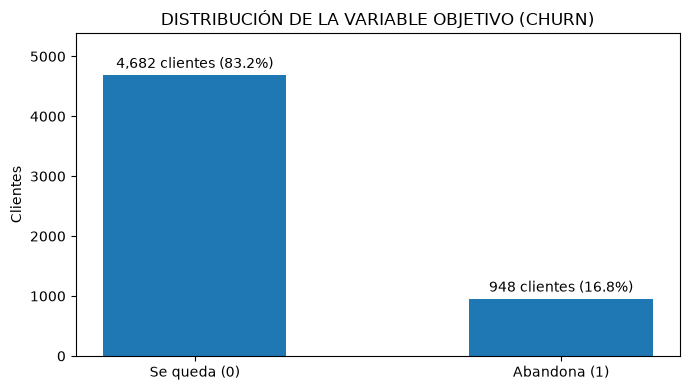

In [12]:
# Graficando distribucion de variable target

conteo = df[target].value_counts().sort_index()

plt.figure(figsize=(7, 4))
barras = plt.bar(["Se queda (0)", "Abandona (1)"], conteo.values, width=0.5)
plt.bar_label(barras, labels=[f"{v:,} clientes ({v / conteo.sum():.1%})" for v in conteo.values], padding=3)
plt.title("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (CHURN)")
plt.ylabel("Clientes")
plt.ylim(0, conteo.max() * 1.15)
plt.tight_layout()
plt.show()

**Conclusión variable objetivo:** el **16.8%** de los clientes abandona (948 de 5,630).Las clases están **desbalanceadas** .


### 6-Variables numéricas

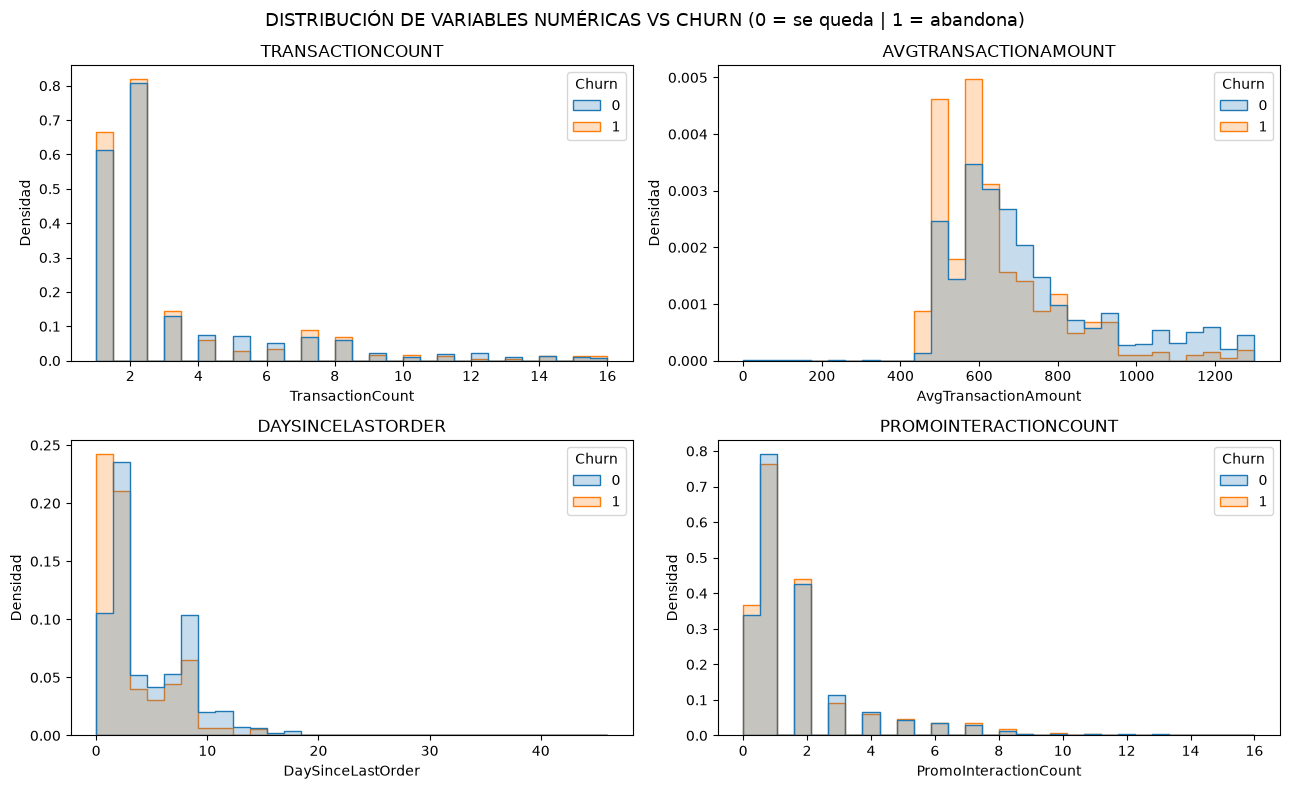

In [13]:
# Graficando distribuciones de variables numericas segun churn

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col in zip(axes.flatten(), cols_numericas):
    sb.histplot(data=df, x=col, hue=target, bins=30, stat="density", common_norm=False, element="step", ax=ax)
    ax.set_title(col.upper())
    ax.set_ylabel("Densidad")

fig.suptitle("DISTRIBUCIÓN DE VARIABLES NUMÉRICAS VS CHURN (0 = se queda | 1 = abandona)", fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# Comparando promedio y mediana de cada variable por grupo de churn

df.groupby(target)[cols_numericas].agg(["mean", "median"]).round(2).T

Churn                              0       1
TransactionCount      mean      2.99    2.81
                      median    2.00    2.00
AvgTransactionAmount  mean    722.54  641.48
                      median  664.46  598.64
DaySinceLastOrder     mean      4.71    3.22
                      median    3.00    2.50
PromoInteractionCount mean      1.72    1.71
                      median    1.00    1.00

**Conclusión variables numéricas:**

- **`AvgTransactionAmount`:** quienes abandonan gastan menos por transacción (promedio 641.48 vs 722.54)... en otras palabras, a menor gasto, mayor riesgo.
- **`TransactionCount` y `PromoInteractionCount`:** casi no hay diferencia entre grupos. Por si solas aportan poca información.
- Todas las distribuciones son **asimétricas a la derecha** 


### 7-Variables categóricas y binarias

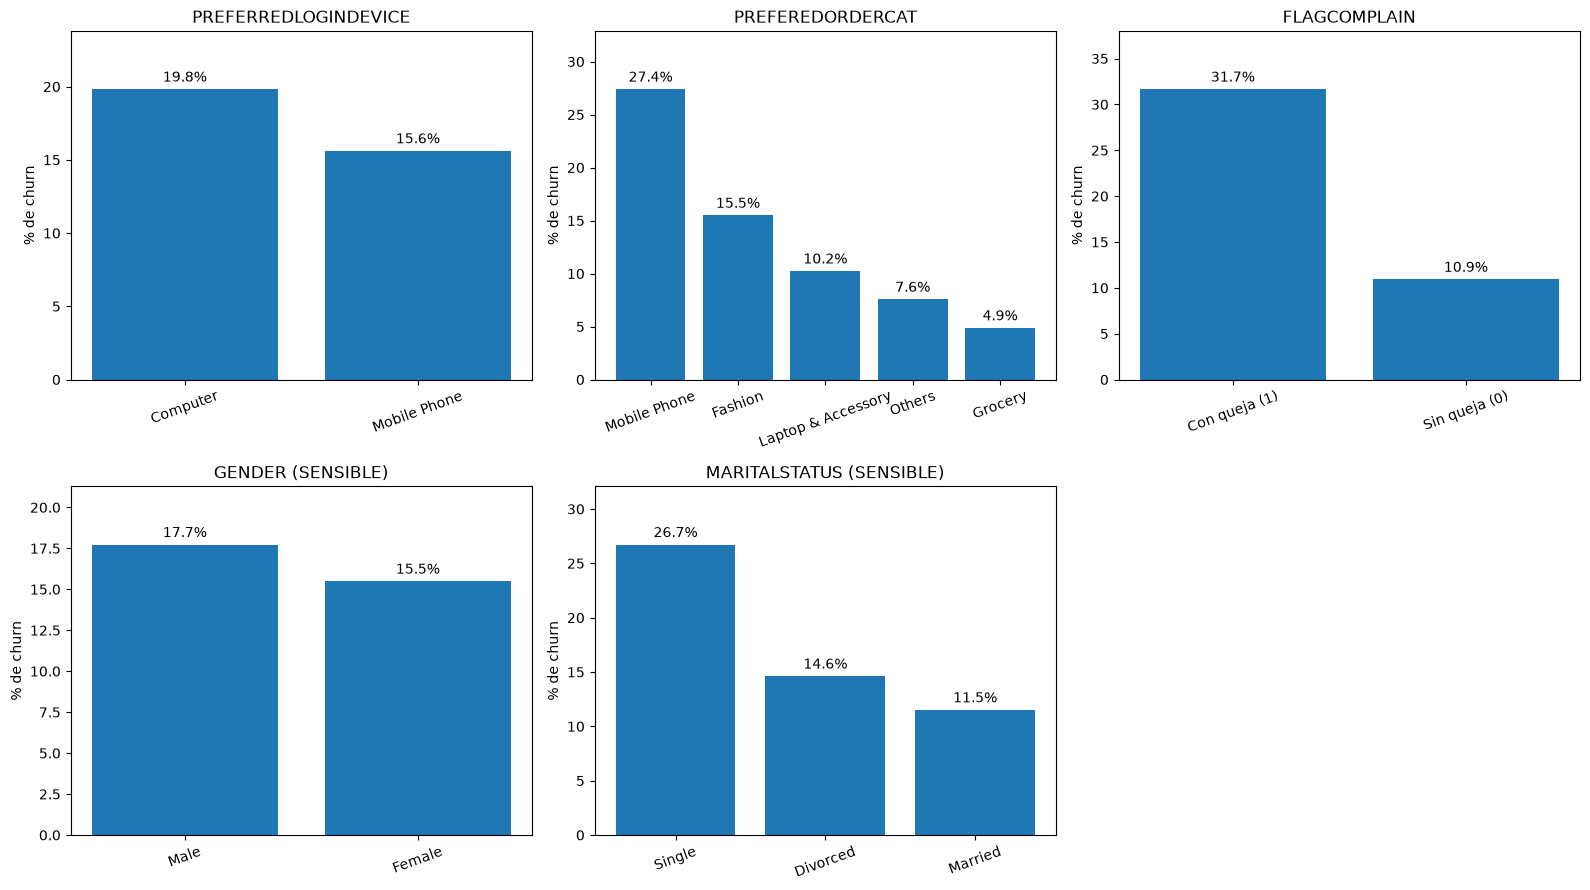

In [15]:
# Graficando tasa de churn por categoria

cols_graficar = cols_categoricas + cols_sensibles
tasa_promedio = df[target].mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), cols_graficar):
    tasa = (df.groupby(col)[target].mean() * 100).sort_values(ascending=False)
    if col == "FlagComplain":
        tasa = tasa.rename({1: "Con queja (1)", 0: "Sin queja (0)"})
    barras = ax.bar(tasa.index.astype(str), tasa.values)
    ax.bar_label(barras, fmt="%.1f%%", padding=3, bbox=dict(facecolor="white", edgecolor="none", pad=1))
    ax.set_title(col.upper() + (" (SENSIBLE)" if col in cols_sensibles else ""))
    ax.set_ylabel("% de churn")
    ax.set_ylim(0, tasa.max() * 1.2)
    ax.tick_params(axis="x", rotation=20)

axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

**Conclusión variables categóricas**:

- **`FlagComplain`:** es la variable más relevante: los clientes con queja abandonan **31.7%** vs **10.9%** sin queja (casi 3 veces más).
- **`PreferedOrderCat`:** quienes compran **celulares (Mobile Phone)** abandonan 27.4%, mientras que los de **Grocery** solo 4.9%.


### 8-Correlaciones

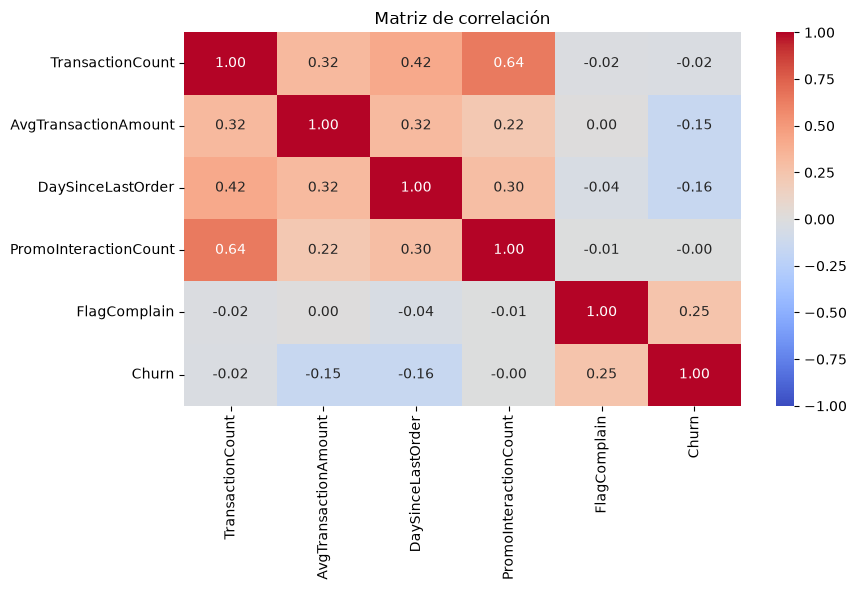

In [16]:
# Generando heatmap

correlaciones = df[cols_numericas + ["FlagComplain", target]].corr()

plt.figure(figsize=(9, 6))

sb.heatmap(
    correlaciones,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

**Conclusión correlación:**

- **`TransactionCount` y `PromoInteractionCount` (0.65):** correlación moderada-fuerte 
- **Relación con `Churn`:** `FlagComplain` (0.24) es la más fuerte; `AvgTransactionAmount` (-0.15) y `DaySinceLastOrder` (-0.15) tienen una relación negativa débil


### 9-Verificación de supuesto de la Regresión Logística

**Multicolinealidad (VIF)**

Criterio: VIF < 5 aceptable, VIF > 10 multicolinealidad alta.

In [17]:
# Calculando VIF de las variables numericas

X_vif = add_constant(df[cols_numericas + ["FlagComplain"]])

vif = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i).round(2) for i in range(X_vif.shape[1])]
})

vif[vif["variable"] != "const"]

,variable,VIF
1,TransactionCount,1.94
2,AvgTransactionAmount,1.17
3,DaySinceLastOrder,1.28
4,PromoInteractionCount,1.70
5,FlagComplain,1.00


### 10-Implementación del modelo

#### 10.1-Preparación de datos

In [18]:
# Definiendo variables predictoras (X) y variable objetivo (y)

X = pd.get_dummies(df[cols_modelo], drop_first=True, dtype=int)
y = df[target]

print(X.shape)
X.head(5)

(5630, 10)


,TransactionCount,AvgTransactionAmount,DaySinceLastOrder,PromoInteractionCount,FlagComplain,PreferredLoginDevice_Mobile Phone,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others
0,1.0,639.72,5.0,1.0,1,1,0,1,0,0
1,1.0,483.60,0.0,0.0,1,1,0,0,1,0
2,1.0,481.12,3.0,0.0,1,1,0,0,1,0
3,1.0,536.28,3.0,0.0,0,1,0,1,0,0
4,1.0,518.40,3.0,1.0,0,1,0,0,1,0


#### 10.2-División en entrenamiento y prueba

In [19]:
# Dividiendo datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27092026, stratify=y)

print(f"X_train: {X_train.shape} | % churn: {y_train.mean():.1%}")
print(f"X_test: {X_test.shape} | % churn: {y_test.mean():.1%}")

X_train: (4504, 10) | % churn: 16.8%
X_test: (1126, 10) | % churn: 16.9%


#### 10.3-Regresión Logística

In [20]:
# Escalando variables 
# El scaler se ajusta SOLO con train para no filtrar informacion del conjunto de prueba - lo dijo Rafa

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenando modelo de regresion logistica
# class_weight="balanced" da mas peso a la clase minoritaria (churn = 1)

modelo_logit = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=27092026)
modelo_logit.fit(X_train_scaled, y_train)

pred_logit = modelo_logit.predict(X_test_scaled)
proba_logit = modelo_logit.predict_proba(X_test_scaled)[:, 1]

print("Clientes de prueba marcados en riesgo:", pred_logit.sum(), "de", len(pred_logit))

Clientes de prueba marcados en riesgo: 470 de 1126


#### 10.4-Árbol de decisión

In [21]:
# Entrenando modelo de arbol de decision

modelo_arbol = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)
proba_arbol = modelo_arbol.predict_proba(X_test)[:, 1]

print("Clientes de prueba marcados en riesgo:", pred_arbol.sum(), "de", len(pred_arbol))

Clientes de prueba marcados en riesgo: 346 de 1126


### 11-Comparación de métricas

| Métrica | ¿Qué responde? |
|---|---|
| **Accuracy** | ¿Qué % de todas las predicciones fue correcto? |
| **Precision** | De los clientes que el modelo marcó en riesgo, ¿cuántos realmente se iban? |
| **Recall** | De los clientes que realmente se iban, ¿cuántos detectó el modelo? | 
| **F1-score** | Promedio armónico entre Precision y Recall | 
| **ROC-AUC** | ¿Qué tan bien ordena a los clientes de mayor a menor riesgo? (0.5 = azar, 1 = perfecto) | 

In [22]:
# Funcion para calcular las metricas de clasificacion

def calcular_metricas(y_real, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred),
        "Recall": recall_score(y_real, y_pred),
        "F1-score": f1_score(y_real, y_pred),
        "ROC-AUC": roc_auc_score(y_real, y_proba)
    }

In [23]:
# Comparando metricas de ambos modelos en el conjunto de prueba
# La linea base representa un modelo que siempre predice "se queda" (0)

resultados = pd.DataFrame({
    "Regresión Logística": calcular_metricas(y_test, pred_logit, proba_logit),
    "Árbol de Decisión": calcular_metricas(y_test, pred_arbol, proba_arbol),
}).round(3)

resultados

,Regresión Logística,Árbol de Decisión
Accuracy,0.655,0.718
Precision,0.289,0.315
Recall,0.716,0.574
F1-score,0.412,0.407
ROC-AUC,0.738,0.729


**Conclusión métricas:**

- **Regresión Logística:** detecta más clientes que se van (**Recall 0.716** vs 0.574) y ordena mejor por riesgo (**ROC-AUC 0.738** vs 0.729).
- **Árbol de Decisión:** es más preciso (**Precision 0.315** vs 0.289), con mejor F1 (0.407 vs 0.412) y mayor accuracy (0.718 vs 0.655), porque genera menos alertas.
- Ambos modelos tienen un **desempeño moderado** 

### 12-Matrices de confusión

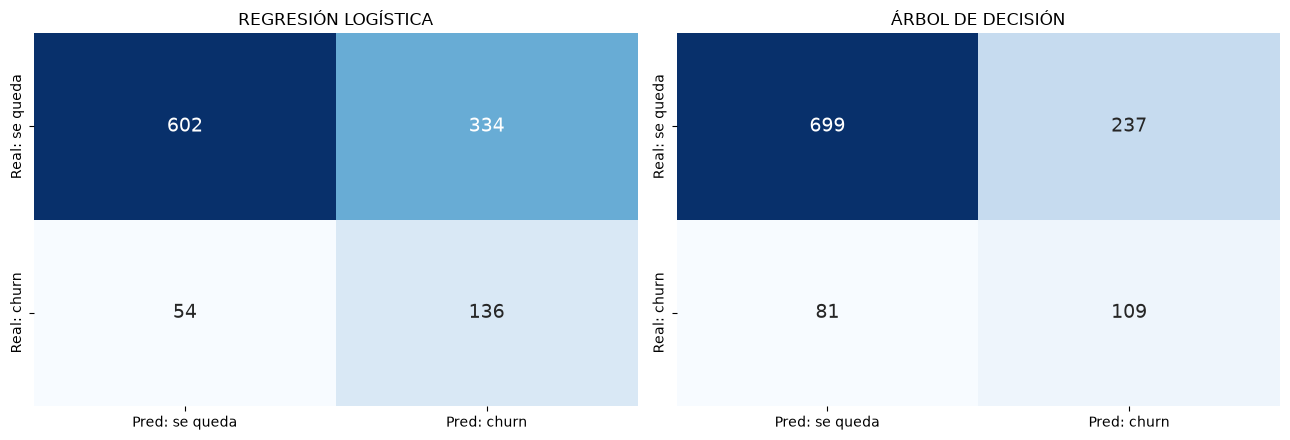

In [29]:
# Graficando matrices de confusion

etiquetas_x = ["Pred: se queda", "Pred: churn"]
etiquetas_y = ["Real: se queda", "Real: churn"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, nombre, pred in zip(axes, ["Regresión Logística", "Árbol de Decisión"], [pred_logit, pred_arbol]):
    matriz = confusion_matrix(y_test, pred)
    sb.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
               xticklabels=etiquetas_x, yticklabels=etiquetas_y, annot_kws={"size": 14})
    ax.set_title(nombre.upper())

plt.tight_layout()
plt.show()

# TN (Clase 0 predicha correctamente), FP (Clase 0 predicha incorrectamente como 1)
# FN (Clase 1 predicha incorrectamente como 0), TP (Clase 1 predicha correctamente)

**Lectura de matrices**:

| | Regresión Logística | Árbol de Decisión |
|---|:---:|:---:|
| Clientes en riesgo detectados (TP) | **68** | 59 |
| Clientes que se van sin ser detectados (FN) | **27** | 36 |
| Incentivos a clientes que no se iban (FP) | 175 | **122** |
| Clientes contactados en total (TP + FP) | 243 | 181 |


### 13-Riesgos del modelo

In [28]:
# Comparando metricas en entrenamiento vs prueba (una brecha grande indica overfitting)

comparacion = pd.DataFrame({
    "Logística - Train": calcular_metricas(y_train, modelo_logit.predict(X_train_scaled), modelo_logit.predict_proba(X_train_scaled)[:, 1]),
    "Logística - Test": calcular_metricas(y_test, pred_logit, proba_logit),
    "Árbol - Train": calcular_metricas(y_train, modelo_arbol.predict(X_train), modelo_arbol.predict_proba(X_train)[:, 1]),
    "Árbol - Test": calcular_metricas(y_test, pred_arbol, proba_arbol)
}).round(3)

comparacion

,Logística - Train,Logística - Test,Árbol - Train,Árbol - Test
Accuracy,0.680,0.655,0.749,0.718
Precision,0.305,0.289,0.362,0.315
Recall,0.708,0.716,0.641,0.574
F1-score,0.427,0.412,0.462,0.407
ROC-AUC,0.764,0.738,0.755,0.729


**Conclusión overfitting:**

- **Regresión Logística:** métricas de train y test casi idénticas (F1 0.427 vs 0.412)... **sin overfitting**
- **Árbol de decisión:** brecha pequeña (F1 0.462 vs 0.407) ... todo normal controlado

### 14-Consideraciones éticas


¿Podría el modelo generar sesgos o discriminación?

`Gender` y `MaritalStatus` **no se usaron para entrenar**, se asumió que eran variables sensibles y poco éticas incorporarlas, por lo que para este caso el modelo no podría tener ningún tipo de discriminación que vaya en contra de lo ético

### 15-¿Cómo garantizar transparencia para los stakeholders?


| Stakeholder | ¿Qué necesita conocer? | Acción |
|---|---|---|
| Negocio | Qué hace el modelo, cuánto acierta y cuáles son sus límites | Resumen ejecutivo en lenguaje de negocio|
| Retención | Por qué un cliente está en riesgo y qué hacer | Factores de riesgo |
|  Equipo de datos | Cómo se construyó y cómo mantenerlo | Documentación del modelo  |


---

## CONCLUSIONES

### Modelo recomendado: Regresión Logística


1. **Cumple el objetivo prioritario:** detecta al **71.6%** de los clientes que se van, 9.5 puntos más que el árbol.
2. **Mejor ROC-AUC:** permite ordenar la lista de contacto y **ajustar el umbral** según el presupuesto de cada estrategia.
3. **Estable y confiable:** no presenta overfitting
4. **Explicable:** sus probabilidades permiten afirmar, por ejemplo, que *una queja multiplica por ≈ 3.9 las odds de abandono*.


### Posibles mejoras

Dentro de los siguientes pasos puede existir un monitoreo en producción, donde a lo mejor se identifiquen desvios de datos por parte del área de retención
